In [1]:
import os
os.chdir("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pipelines.cb.catboost_pipe import CatBoostPipe
import pprint

pipe = CatBoostPipe()

In [6]:
hook_name = "hooks/hook_87c" #"hook_057" hook_87c
trials_type = "vertical"

trials = pipe.load(f"trials/{trials_type}_trials")
# hook = pipe.load("hook_ffd")[3] # verticals
hook = pipe.load(hook_name)
print(len(hook))
hook

1


[      Vertical 2.78_0  Vertical 2.78_1  Vertical 2.78_2  Vertical 2.78_3  \
 0           16250.845        116050.45       115637.930        114968.81   
 1           33416.750        115713.68       115645.580        114999.90   
 2           59605.078        115814.45       115546.940        115034.69   
 3          226297.190        115744.92       115540.030        114965.95   
 4          152904.420        115735.56       115521.800        115040.73   
 ...               ...              ...              ...              ...   
 2611        95892.883              NaN       129303.920              NaN   
 2612        97362.266              NaN       280520.500              NaN   
 2613        91477.414              NaN        44410.813              NaN   
 2614       120884.140              NaN        45118.348              NaN   
 2615        74202.773              NaN        62299.637              NaN   
 
       Vertical 2.78_4  Vertical 2.78_5  Vertical 2.78_6  Vertical 2.78_7 

In [7]:
# Create a vector from 0 to 2.1471 with the same number of points as hook[0].iloc[:,1]
hook_all = pipe.load(hook_name)
num_points = len(hook_all[0].iloc[:, 1])
vector = np.linspace(0, 2.1471, num_points)

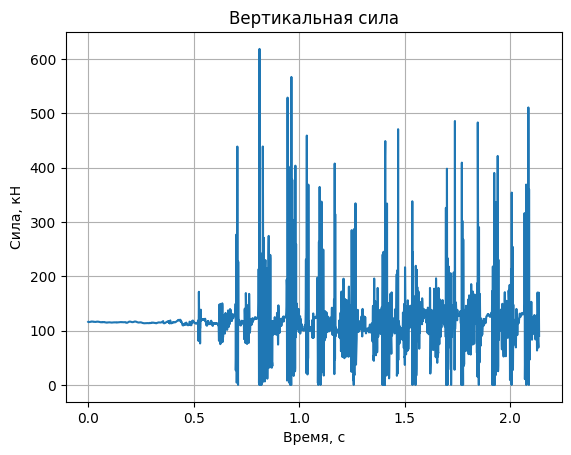

In [8]:
arr = hook[0].iloc[:,1]/1000
arr.index = vector
plt.plot(arr)
plt.title(f"Вертикальная сила")
plt.xlabel("Время, с")
plt.ylabel("Cила, кН")
plt.grid()
plt.show()

In [9]:
arr.values

array([116.05045, 115.71368, 115.81445, ...,       nan,       nan,
             nan], shape=(2616,))

После медианной фильтрации
СКО до: 51.0174, после: 24.3757
Уровень шума: 0.243757


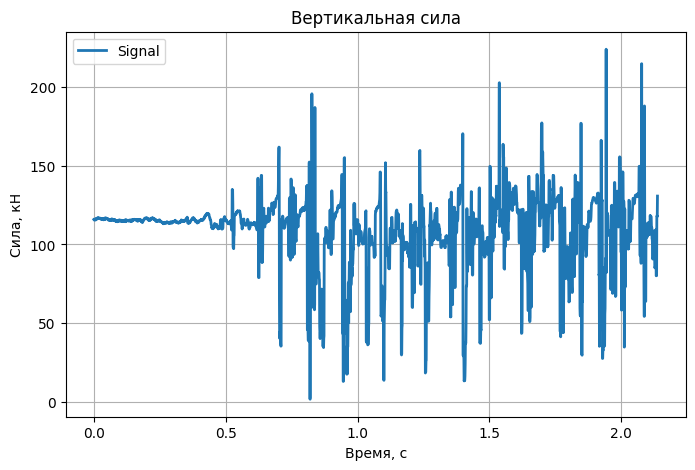

min: 1.7763144349113666
max: 223.87816510784506
mean: 107.79121281045053
std: 24.37597487588772


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# y: возьми один столбец, если arr — DataFrame
y = arr.to_numpy() if hasattr(arr, "iloc") else np.asarray(arr)
y = y.squeeze()  # 1D

t = np.asarray(vector).squeeze()

# маска валидных значений
mask = np.isfinite(y)
y = y[mask]
t = t[mask]

# медианная фильтрация
y_smooth = median_filter(y, size=5)

print("После медианной фильтрации")
print(f"СКО до: {np.std(y):.4f}, после: {np.std(y_smooth):.4f}")

# шум
noise_level = 0.01 * np.std(y_smooth)
noise = np.random.normal(0, noise_level, size=y_smooth.shape)
y_noisy = y_smooth + noise
print(f"Уровень шума: {noise_level:.6f}")

plt.figure(figsize=(8,5))
plt.title("Вертикальная сила")
plt.plot(t, y_noisy, linewidth=2, label="Signal")
plt.legend()
plt.xlabel("Время, с")
plt.ylabel("Cила, кН")
plt.grid()
plt.show()

print("min:", np.min(y_noisy))
print("max:", np.max(y_noisy))
print("mean:", np.mean(y_noisy))
print("std:", np.std(y_noisy))

In [232]:
hook_mask = arr>13
arr = arr[hook_mask]
arr

0.000000    116.050450
0.000821    115.713680
0.001642    115.814450
0.002463    115.744920
0.003284    115.735560
               ...    
2.133963     68.735023
2.134784    117.782910
2.135605    169.885300
2.136426    130.463060
2.137247     90.479367
Name: Vertical 2.78_1, Length: 2551, dtype: float64

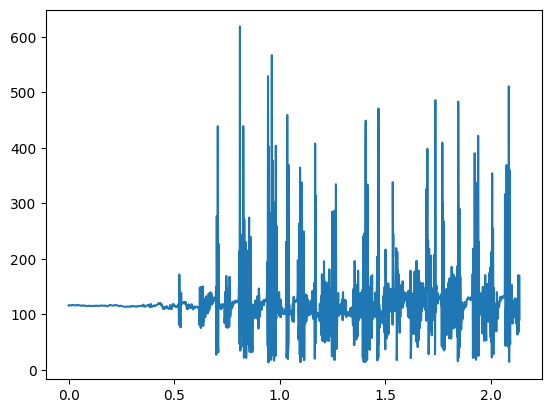

In [233]:
plt.plot(arr)

In [234]:
trials[1]

{'v': 40,
 'start_num': 547,
 'end_num': 552,
 'peaks': [88.39349365234375,
  96.45755004882812,
  99.89820861816406,
  84.20018005371094,
  112.84708404541016,
  107.07646942138672,
  114.49583435058594,
  112.53794860839844,
  350.0,
  178.77310180664062,
  350.0,
  350.0,
  89.21524810791016,
  87.03646087646484,
  102.08042907714844,
  89.00774383544922,
  350.0,
  350.0,
  350.0,
  350.0,
  87.85588836669922,
  95.81242370605469,
  97.96283721923828,
  83.77009582519531,
  90.97399139404297,
  123.5639419555664,
  113.25926971435547,
  129.95285034179688,
  112.64099884033203,
  113.25926971435547,
  350.0,
  350.0,
  350.0,
  350.0,
  350.0,
  82.57514953613281,
  96.58159637451172,
  76.66131591796875,
  92.43153381347656,
  23.0,
  27.55240249633789,
  27.455764770507812,
  28.132238388061523,
  28.325515747070312,
  28.615432739257812,
  88.93109130859375,
  97.53275299072266,
  100.32829284667969,
  84.30770111083984,
  111.30138397216797,
  107.3856201171875,
  114.186698913

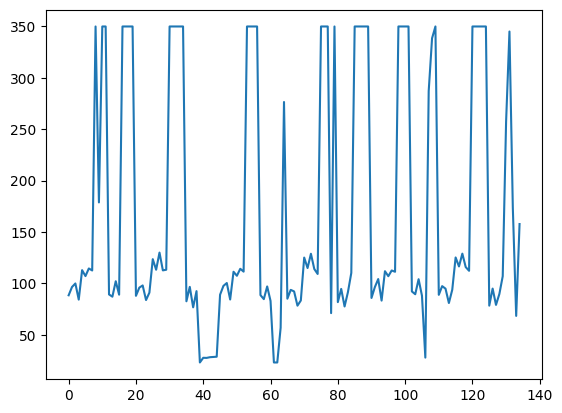

In [235]:
plt.plot(trials[1]["peaks"])

In [246]:
from scipy.signal import find_peaks

hook_all = pipe.load(hook_name)
print(f"Number of hook simulations: {len(hook_all)}")

all_peaks_from_simulations = []

for i, simulation in enumerate(hook_all):
    for col in simulation.columns:
        signal = simulation[col] / 1000
        signal_clean = signal[~np.isnan(signal)].values

        if len(signal_clean) == 0:
            continue

        peaks_idx, _ = find_peaks(signal_clean, height=0, distance=1)
        peaks_vals = signal_clean[peaks_idx]

        # ---- ВОТ ГДЕ КОНТЕКСТ ----
        if "Vertical" in col:
            # вертикальная сила
            peaks_filtered = peaks_vals[
                (peaks_vals >= 50) & (peaks_vals <= 200)
            ]

        elif "Side" in col:
            # боковая сила
            peaks_filtered = peaks_vals[
                peaks_vals > 0
            ]

        else:
            # неизвестный тип — пропускаем
            continue

        all_peaks_from_simulations.extend(peaks_filtered.tolist())

all_peaks_from_simulations = np.array(all_peaks_from_simulations)
# для боковой
# mask = (all_peaks_from_simulations < 10) & (all_peaks_from_simulations > 0.1)
# all_peaks_from_simulations = all_peaks_from_simulations[mask]
print(f"Total peaks found across all simulations: {len(all_peaks_from_simulations)}")


Number of hook simulations: 1
Total peaks found across all simulations: 10915


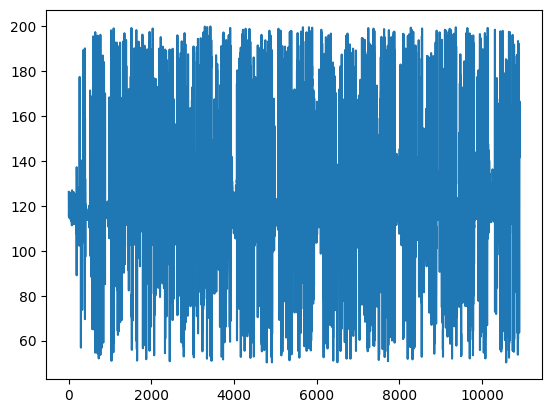

In [247]:
plt.plot(all_peaks_from_simulations)

In [236]:
trial_force = np.array(trials[1]["peaks"])
trial_force_filtered = trial_force[(trial_force<=200) & (trial_force>=50)]

ИСХОДНЫЕ ВЕКТОРЫ: Моделирование vs ИСПЫТАНИЯ

До интерполяции:
Длина вектора симуляции: 10915
Длина вектора испытаний: 86

После интерполяции:
Длина вектора симуляции: 10915
Длина вектора испытаний (интерполированных): 10915

Моделирование   - Mean: 127.8490, Std: 29.2472, Min: 50.2662, Max: 199.9698
Испытания   - Mean: 100.0919, Std: 18.7657, Min: 56.8340, Max: 178.7731


/tmp/ipykernel_72450/68293728.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([real_interpolated, sim_sorted], labels=['Испытания', 'Моделирование'])


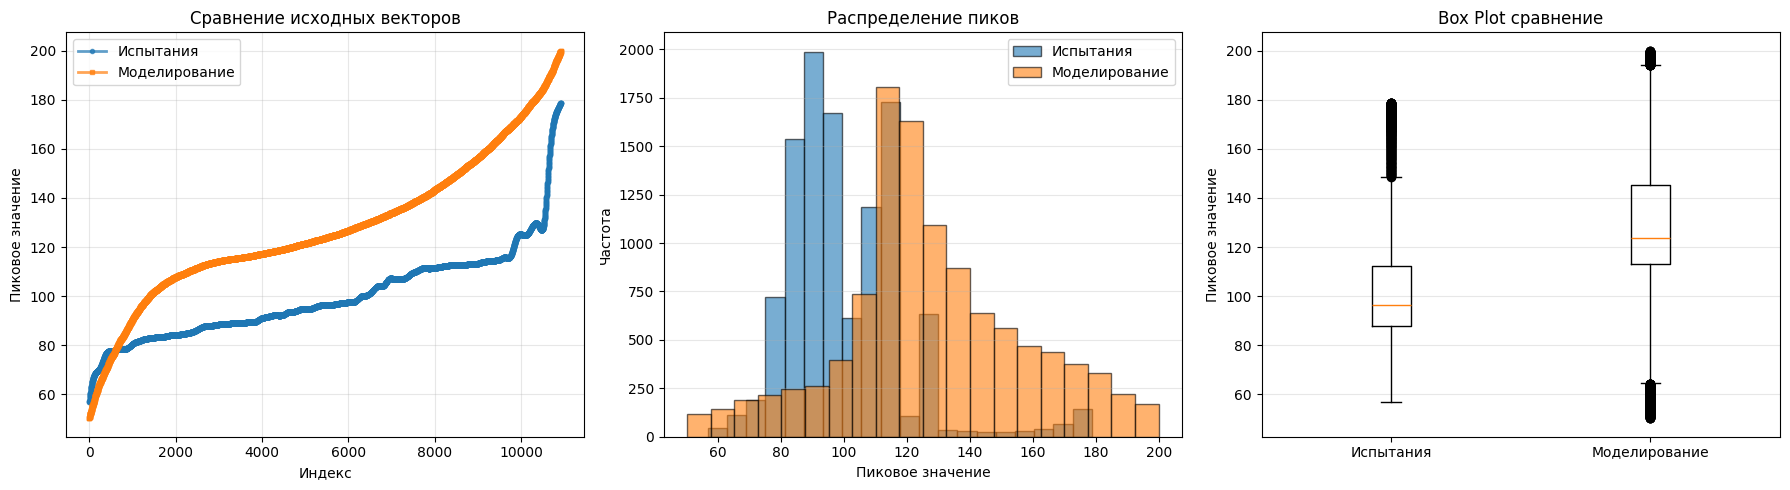

In [248]:
# Визуализация исходных векторов (без нормализации)
from scipy.interpolate import interp1d

print("="*70)
print("ИСХОДНЫЕ ВЕКТОРЫ: Моделирование vs ИСПЫТАНИЯ")
print("="*70)

sim_sorted = np.sort(all_peaks_from_simulations)
real_sorted = np.sort(trial_force_filtered)

print(f"\nДо интерполяции:")
print(f"Длина вектора симуляции: {len(sim_sorted)}")
print(f"Длина вектора испытаний: {len(real_sorted)}")

# Интерполируем испытания к размеру симуляции
x_old = np.linspace(0, 1, len(real_sorted))
x_new = np.linspace(0, 1, len(sim_sorted))
f_interp = interp1d(x_old, real_sorted, kind='cubic')
real_interpolated = f_interp(x_new)

print(f"\nПосле интерполяции:")
print(f"Длина вектора симуляции: {len(sim_sorted)}")
print(f"Длина вектора испытаний (интерполированных): {len(real_interpolated)}")

print(f"\nМоделирование   - Mean: {np.mean(sim_sorted):.4f}, Std: {np.std(sim_sorted):.4f}, Min: {np.min(sim_sorted):.4f}, Max: {np.max(sim_sorted):.4f}")
print(f"Испытания   - Mean: {np.mean(real_interpolated):.4f}, Std: {np.std(real_interpolated):.4f}, Min: {np.min(real_interpolated):.4f}, Max: {np.max(real_interpolated):.4f}")

# График исходных векторов
# --- График исходных векторов ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Оба вектора на одном графике
axes[0].plot(real_interpolated, 'o-', label='Испытания', linewidth=2, markersize=3, alpha=0.7)
axes[0].plot(sim_sorted, 's-', label='Моделирование', linewidth=2, markersize=3, alpha=0.7)
axes[0].set_xlabel('Индекс')
axes[0].set_ylabel('Пиковое значение')
axes[0].set_title('Сравнение исходных векторов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Гистограммы
axes[1].hist(real_interpolated, bins=20, alpha=0.6, label='Испытания', edgecolor='black')
axes[1].hist(sim_sorted, bins=20, alpha=0.6, label='Моделирование', edgecolor='black')
axes[1].set_xlabel('Пиковое значение')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение пиков')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Box plot
axes[2].boxplot([real_interpolated, sim_sorted], labels=['Испытания', 'Моделирование'])
axes[2].set_ylabel('Пиковое значение')
axes[2].set_title('Box Plot сравнение')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [249]:
import numpy as np
from scipy.stats import wasserstein_distance, ks_2samp

sim = np.asarray(sim_sorted)
real = np.asarray(real_interpolated)


# 1) приводим к одной длине (если разные)
n = min(len(sim), len(real))
sim = sim[:n]
real = real[:n]

# 2) KS (разница CDF)
ks_stat, ks_p = ks_2samp(sim, real)

# 3) Wasserstein distance
wd = wasserstein_distance(sim, real)
wd_pct = wd / (np.mean(np.abs(real)) + 1e-12) * 100

# 4) Квантильные расхождения
qs = [5, 10, 25, 50, 75, 90, 95]
q_rows = []
for q in qs:
    s = np.percentile(sim, q)
    r = np.percentile(real, q)
    dq = (s - r) / (abs(r) + 1e-12) * 100
    q_rows.append((q, s, r, dq))

# 5) “масштаб” (быстро понять систематический сдвиг)
scale_med = (np.median(sim) / (np.median(real) + 1e-12))
scale_mean = (np.mean(sim) / (np.mean(real) + 1e-12))

print("="*60)
print("СРАВНЕНИЕ ОТСОРТИРОВАННЫХ ВЕКТОРОВ (РАСПРЕДЕЛЕНИЙ)")
print("="*60)
print(f"KS statistic: {ks_stat:.4f} | p-value: {ks_p:.2e}")
print(f"Wasserstein distance: {wd:.4f} | WD% (от среднего |real|): {wd_pct:.2f}%")
print(f"Scale (median sim/real): {scale_med:.3f}")
print(f"Scale (mean sim/real):   {scale_mean:.3f}")

print("\nКвантильные расхождения:")
print(f"{'q':>4} {'sim':>12} {'real':>12} {'Δ%':>10}")
for q, s, r, dq in q_rows:
    print(f"{q:>4} {s:>12.4f} {r:>12.4f} {dq:>+9.2f}%")

# Итоговая “оценка” по квантилям (понятно для отчёта)
avg_q_gap = np.median([abs(x[3]) for x in q_rows])
print(f"\nИтог: среднее абсолютное расхождение по квантилям ≈ {avg_q_gap:.1f}%")

СРАВНЕНИЕ ОТСОРТИРОВАННЫХ ВЕКТОРОВ (РАСПРЕДЕЛЕНИЙ)
KS statistic: 0.5796 | p-value: 0.00e+00
Wasserstein distance: 28.4374 | WD% (от среднего |real|): 28.41%
Scale (median sim/real): 1.282
Scale (mean sim/real):   1.277

Квантильные расхождения:
   q          sim         real         Δ%
   5      75.9009      77.6079     -2.20%
  10      93.0168      81.3903    +14.28%
  25     113.0363      87.9123    +28.58%
  50     123.6616      96.4312    +28.24%
  75     145.4279     112.1289    +29.70%
  90     170.1176     119.8728    +41.92%
  95     181.1068     128.5894    +40.84%

Итог: среднее абсолютное расхождение по квантилям ≈ 28.6%
